# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:
import tensorflow

In [3]:

from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [4]:
# Inspect the shapes of the datasets
# 2. Inspect shapes
print("Training data shape:", X_train.shape)  # (60000, 28, 28)
print("Test data shape:", X_test.shape)       # (10000, 28, 28)
print("Training labels shape:", y_train.shape)
print("Test labels shape:", y_test.shape)


# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical

# One-hot encoded labels
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

print("One-hot encoded training labels shape:", y_train_cat.shape)  # (60000, 10)
print("One-hot encoded test labels shape:", y_test_cat.shape)

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)
Training labels shape: (60000,)
Test labels shape: (10000,)
One-hot encoded training labels shape: (60000, 10)
One-hot encoded test labels shape: (10000, 10)


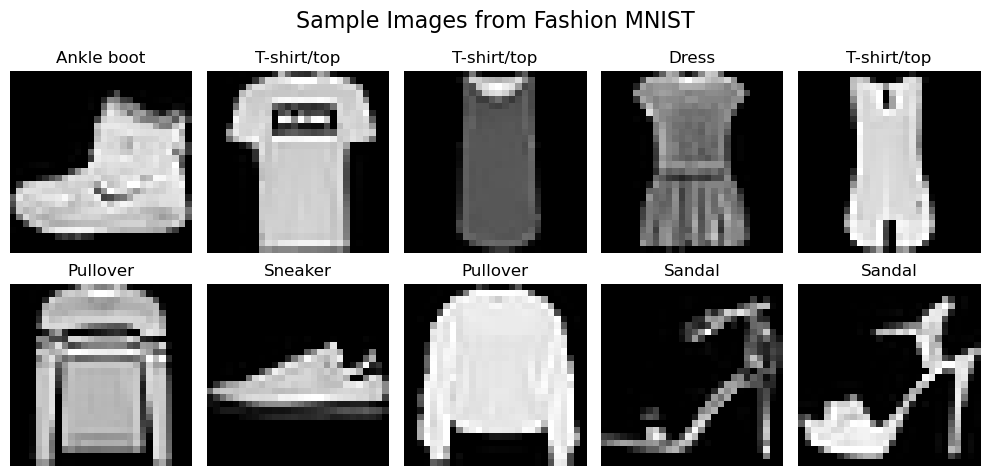

In [5]:
import matplotlib.pyplot as plt
# Verify the data looks as expected

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.suptitle("Sample Images from Fashion MNIST", fontsize=16)
plt.tight_layout()
plt.show()


In [6]:
# lets see whether the data has class balance

import numpy as np 

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

for label, count in enumerate(np.bincount(y_train)):
    print(f"{label} - {class_names[label]}: {count} samples")

0 - T-shirt/top: 6000 samples
1 - Trouser: 6000 samples
2 - Pullover: 6000 samples
3 - Dress: 6000 samples
4 - Coat: 6000 samples
5 - Sandal: 6000 samples
6 - Shirt: 6000 samples
7 - Sneaker: 6000 samples
8 - Bag: 6000 samples
9 - Ankle boot: 6000 samples


Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

The data looks as expected but the quality of image is quite poor and in black and white, which makes them challenging to define. I would be struggling to find differences between t-shirt/pullover or dress and shirt/top (both images above). The categories have equal number of samples, so the classes are balanced, but would the model be confused due to similar looking items (perceivably) having different labels? I guess we will find out.

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [7]:
from keras.models import Sequential
from keras.layers import Dense, Flatten

# Create a simple linear regression model
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

In [8]:
# Compile the model using `model.compile()`
model.compile(
    optimizer='sgd', 
    loss='categorical_crossentropy', 
    metrics=['accuracy'])

# Train the model with `model.fit()`

model.fit(X_train, y_train_cat, epochs=10, batch_size=32, validation_split=0.1)

# Evaluate the model with `model.evaluate()`

test_loss, test_accuracy = model.evaluate(X_test, y_test_cat)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f'Test Loss : {test_loss:.4f}')

Epoch 1/10
1688/1688 [==============================] - 5s 2ms/step - loss: 0.7695 - accuracy: 0.7561 - val_loss: 0.5574 - val_accuracy: 0.8147
Epoch 2/10
1688/1688 [==============================] - 3s 2ms/step - loss: 0.5227 - accuracy: 0.8234 - val_loss: 0.4968 - val_accuracy: 0.8248
Epoch 3/10
1688/1688 [==============================] - 3s 2ms/step - loss: 0.4748 - accuracy: 0.8382 - val_loss: 0.4664 - val_accuracy: 0.8362
Epoch 4/10
1688/1688 [==============================] - 3s 2ms/step - loss: 0.4488 - accuracy: 0.8448 - val_loss: 0.4391 - val_accuracy: 0.8457
Epoch 5/10
1688/1688 [==============================] - 3s 2ms/step - loss: 0.4297 - accuracy: 0.8521 - val_loss: 0.4527 - val_accuracy: 0.8427
Epoch 6/10
1688/1688 [==============================] - 3s 2ms/step - loss: 0.4163 - accuracy: 0.8567 - val_loss: 0.4317 - val_accuracy: 0.8463
Epoch 7/10
1688/1688 [==============================] - 3s 2ms/step - loss: 0.4051 - accuracy: 0.8605 - val_loss: 0.4222 - val_accuracy:

Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

The accuracy is good but not great. I think we are at the baseline model with linear regression, so there are is much more room to improve accuracy.

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [9]:
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model = Sequential()

# Convolutional layer (32 filters, 3x3 kernel)
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))

# Optional: Add a MaxPooling layer to reduce spatial dimensions
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten the output
model.add(Flatten())

# Fully connected (dense) layer
model.add(Dense(128, activation='relu'))

# Output layer: 10 classes → softmax
model.add(Dense(10, activation='softmax'))

# Summary of architecture
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 13, 13, 32)       0         
 )                                                               
                                                                 
 flatten_1 (Flatten)         (None, 5408)              0         
                                                                 
 dense_2 (Dense)             (None, 128)               692352    
                                                                 
 dense_3 (Dense)             (None, 10)                1290      
                                                                 
Total params: 693,962
Trainable params: 693,962
Non-trainable params: 0
________________________________________________

In [10]:
# Compile the model

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model

model.fit(
    X_train,
    y_train_cat,           # One-hot encoded labels
    epochs=5,
    batch_size=32,
    validation_split=0.2
)
# Evaluate the model

test_loss, test_accuracy = model.evaluate(X_test, y_test_cat)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f'Test Loss : {test_loss:.4f}')

Epoch 1/5
1500/1500 [==============================] - 21s 13ms/step - loss: 0.4139 - accuracy: 0.8537 - val_loss: 0.3272 - val_accuracy: 0.8833
Epoch 2/5
1500/1500 [==============================] - 21s 14ms/step - loss: 0.2795 - accuracy: 0.8983 - val_loss: 0.2862 - val_accuracy: 0.8987
Epoch 3/5
1500/1500 [==============================] - 16s 11ms/step - loss: 0.2302 - accuracy: 0.9159 - val_loss: 0.2734 - val_accuracy: 0.8991
Epoch 4/5
1500/1500 [==============================] - 16s 11ms/step - loss: 0.1977 - accuracy: 0.9266 - val_loss: 0.2562 - val_accuracy: 0.9087
Epoch 5/5
313/313 [==============================] - 5s 15ms/step - loss: 0.2628 - accuracy: 0.9065
Test Accuracy: 90.65%
Test Loss : 0.2628


Reflection: Did the CNN model perform better than the baseline model? If so, by how much? 

Yes, accuracy improved from 85% to 91%. 

# 3. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

In [ ]:
# import adam and dropout that was not imporeted before

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dropout

# List of filter sizes to test
num_filters_list = [16, 32, 64, 128]

# Store results
results = []

# Run experiments for each filter size, with and without dropout
for num_filters in num_filters_list:


# A. Model without Dropout

# Initialize the model
    model = Sequential()
    model.add(Conv2D(num_filters, (3, 3), activation='relu', input_shape=(28, 28, 1)))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(10, activation='softmax'))

# Compile the model

    model.compile(
        optimizer=Adam(),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

# Train the model
    model.fit(X_train, y_train_cat, epochs=5, batch_size=32, validation_split=0.2, verbose=0)
    test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
    
# Record the results
    results.append({'filters': num_filters, 'dropout': False, 'test_accuracy': test_acc})
    print(f"Filters: {num_filters}, Dropout: False → Test Accuracy: {test_acc*100:.2f}%")

    

Filters: 16, Dropout: False → Test Accuracy: 90.39%
Filters: 16, Dropout: True → Test Accuracy: 89.75%
Filters: 32, Dropout: False → Test Accuracy: 90.32%
Filters: 32, Dropout: True → Test Accuracy: 90.19%
Filters: 64, Dropout: False → Test Accuracy: 91.11%
Filters: 64, Dropout: True → Test Accuracy: 89.95%
Filters: 128, Dropout: False → Test Accuracy: 90.95%
Filters: 128, Dropout: True → Test Accuracy: 90.06%


Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

We tried a series of controlled experiments to evaluate the impact of different hyperparameters and regularization techniques on a CNN. We varied the number of filters on the first layer, tested the effect of dropout as a regularization method.

Among all of these models, increasing filters overall led to improved performance with the highest rest accuracy at 64 filters without dropout, reaching at 91.11%.

Adding a dropout overall led to worse performance in accuracy across all the filter sizes. 

The improvement in accuracy performance with more filters can be deemed as model's increased ability to extract more complex spatial features from input images. The returns diminished after 64 filters. Hence, the optimal model was 64 filters without a dropout balancing accuracy performance and complexity.


# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [16]:
# The final model with best settings
model = Sequential()
model.add(Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

# Compile the model
model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    X_train,
    y_train_cat,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat)

print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Final Test Loss: {test_loss:.4f}")

Epoch 1/5
1500/1500 [==============================] - 33s 21ms/step - loss: 0.4054 - accuracy: 0.8577 - val_loss: 0.3049 - val_accuracy: 0.8911
Epoch 2/5
1500/1500 [==============================] - 32s 21ms/step - loss: 0.2728 - accuracy: 0.9012 - val_loss: 0.2828 - val_accuracy: 0.8954
Epoch 3/5
1500/1500 [==============================] - 32s 21ms/step - loss: 0.2250 - accuracy: 0.9178 - val_loss: 0.2553 - val_accuracy: 0.9078
Epoch 4/5
1500/1500 [==============================] - 32s 21ms/step - loss: 0.1902 - accuracy: 0.9297 - val_loss: 0.2607 - val_accuracy: 0.9066
Epoch 5/5
313/313 [==============================] - 2s 5ms/step - loss: 0.2668 - accuracy: 0.9083
Final Test Accuracy: 90.83%
Final Test Loss: 0.2668


Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

The final model run achieved a test accuracy of 90.83%, which is a notable improvement over the baseline dense model and almost comparable to the earlier simple CNN model. 

The baseline model, which used only fully connected layers on flattened inputs, struggled to effectively capture the spatial patterns in the image data. 

The CNN model, by contrast, introduced convolutional layers that preserved spatial structure and significantly boosted performance.

The final model built upon the strengths of the CNN by using 64 filters, which our earlier experiments showed to be the optimal balance between learning capacity and generalization. It also omitted dropout, as this technique slightly reduced performance during controlled testing.

Several factors likely contributed to the strong performance of the final model:

The use of convolutional and pooling layers, which allowed the network to learn spatial hierarchies.

An appropriate number of filters, ensuring the model had enough capacity without overfitting.

A well-tuned learning rate and batch size, along with the Adam optimizer, which facilitated fast and stable training.

If I had more time, I would experiment with:

Adding a second convolutional layer to explore deeper architectures.

Increasing the number of epochs to see if the model can improve further without overfitting.

Overall, the final model demonstrated excellent performance and generalization, making it well-suited for image classification tasks on this dataset.

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 06/07/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-6-ml-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.